In [2]:
import pandas as pd 
from pathlib import Path

In [3]:
data_dir = Path("../OptimizationInput")
base_load_df = pd.read_csv(data_dir / "alamedaBaseLoadDf_slice_month6_hour20.csv")
feeder_capacity_df = pd.read_csv(data_dir / "alamedaMinICA_slice_month6_hour20.csv")
ev_load_df = pd.read_csv(data_dir / "ev_load_growth_from2025unmanaged_to2035managed_slice_hour_20.csv")
feeder_block_map_df = pd.read_csv(data_dir / "feederBlockIntersectionMtx.csv")
ev_network_df = pd.read_parquet(Path("../data/network_analysis/network_df.parquet"))

In [13]:
block_capacity_df = feeder_capacity_df.join(feeder_block_map_df)
total_capacity_per_block = block_capacity_df.iloc[:, 2:].multiply(block_capacity_df['IC_min_kW'], axis=0).sum(axis=0)

In [14]:
total_capacity_per_block

060014001001    1423.814828
060014001002    1737.021698
060014002001     938.414873
060014002002    1531.225661
060014003001    1945.718990
                   ...     
060019819001    2249.995616
060019820001    2574.297961
060019821001    2104.674329
060019832001    1538.637094
060019832002    2231.009805
Length: 1074, dtype: float64

In [17]:
df = ev_network_df.merge(total_capacity_per_block.rename("feeder_capacity_kW"), how="left", left_on="geoid", right_index=True)

In [20]:
df.head(2).to_clipboard()

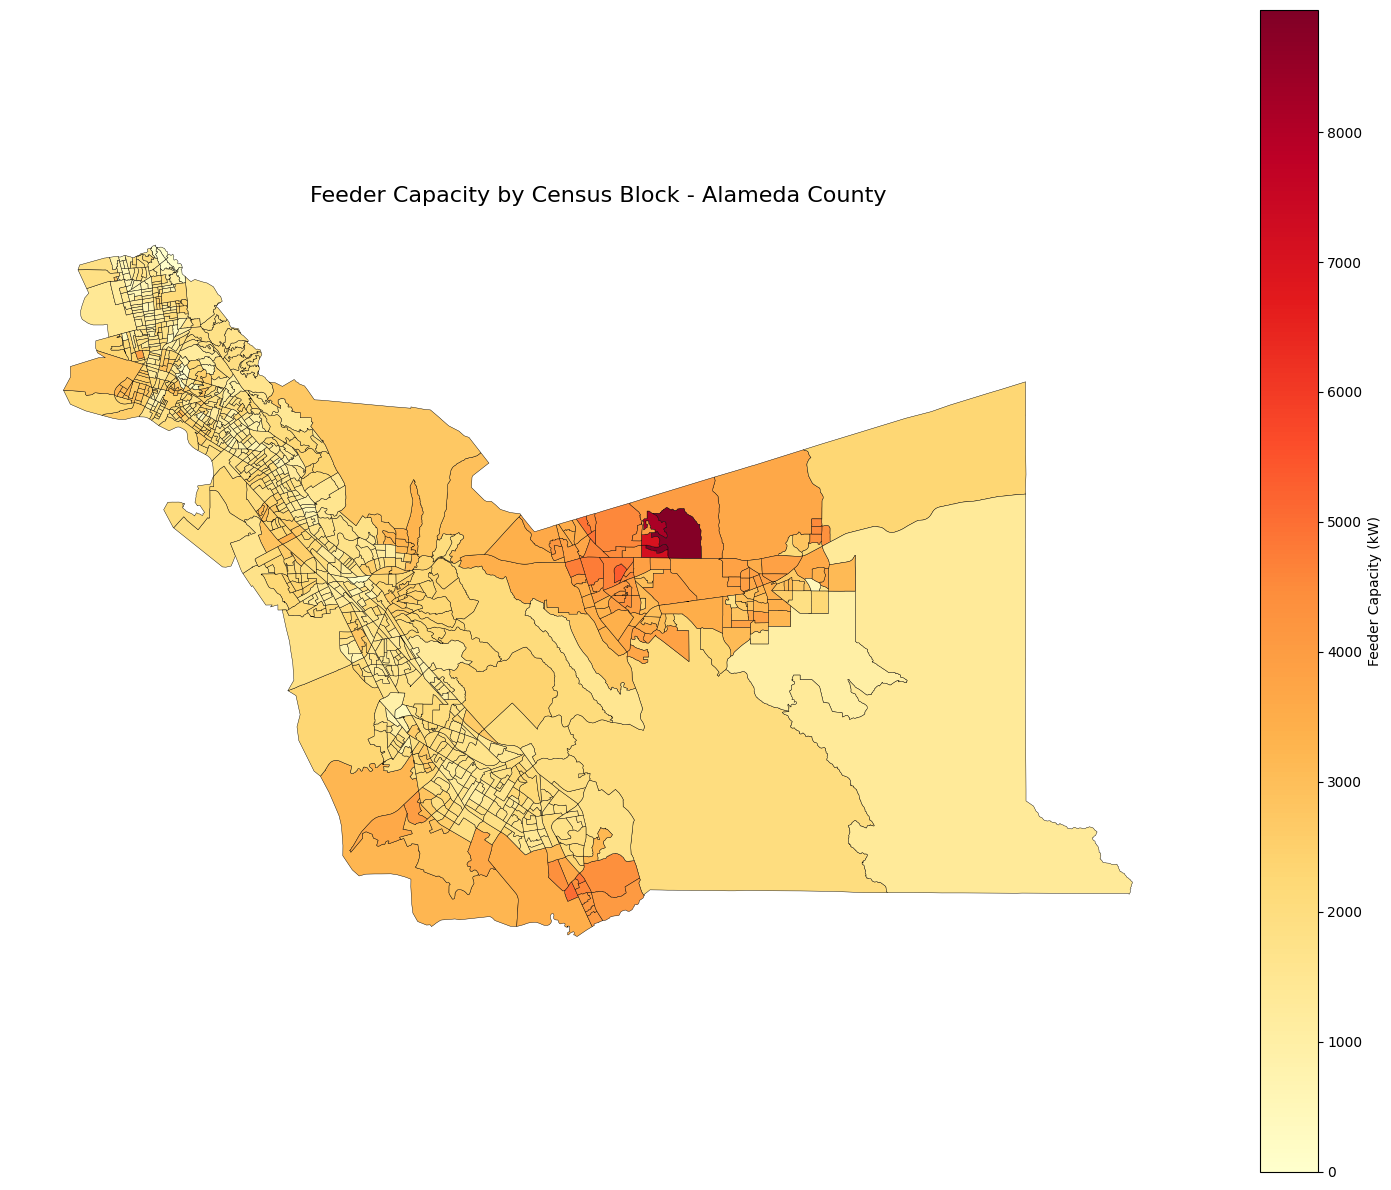

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt

census_blocks = gpd.read_file('/Users/lazlopaul/Desktop/sys_ms/mobility/final-project/OptimalChargerPlacement/data/Geography_Files/location_str_to_geoid_mapping.shp')

# Merge with your capacity data
blocks_unique = df.groupby('geoid').agg({
    'feeder_capacity_kW': 'first'
}).reset_index()

# Merge on GEOID
census_blocks = census_blocks.merge(
    blocks_unique, 
    left_on='GEOID', 
    right_on='geoid', 
    how='left'
)

# Plot
fig, ax = plt.subplots(figsize=(15, 12))

census_blocks.plot(
    ax=ax,
    column='feeder_capacity_kW',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Capacity (kW)',
        'orientation': 'vertical'
    }
)

plt.title('Feeder Capacity by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()